# GraphRAG Lab Day 19 — Tech Company Corpus

## §0 — Setup Check

Verify environment and imports before running the pipeline.

In [1]:
# Add project root to path so imports work from notebook
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import settings
from src.corpus_builder import (
    load_corpus, load_benchmark,
    corpus_stats, benchmark_stats,
    Paragraph, BenchQuestion,
)
print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ LLM model:    {settings.llm_model}")
print(f"✓ Neo4j URI:    {settings.neo4j_uri}")

✓ Project root: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab
✓ LLM model:    gpt-4o-mini
✓ Neo4j URI:    bolt://localhost:7687


## §1 — Theory (Research questions from Lab brief §2.1)

### Q1. How does the LLM distinguish between an Entity (Node) and an Attribute?

An **entity** is something that can act as the subject of multiple relations and that other relations can point to. It has identity beyond a single statement (OpenAI, Sam Altman, Microsoft Azure). An **attribute** is a property *of* an entity that does not itself participate in further relations: a year (2015), a dollar amount (\$13B), a single string label. In our extractor we capture both as triples but tag the object with `object_type ∈ {entity, literal}`. Only `entity` objects become nodes that can be traversed; `literal` objects become node properties or terminal leaves.

### Q2. Why is deduplication critical in graph construction?

Without dedup, "OpenAI", "Open AI" and "OpenAI Inc." become three disconnected nodes. A 2-hop query starting at one of them cannot reach facts attached to the other two — the graph is *fragmented*, not unified. Dedup (via name normalization + alias merging via `MERGE` in Cypher) is what turns a pile of triples into a true knowledge graph. Without it, GraphRAG degenerates to lookup-by-string and loses its multi-hop advantage.

### Q3. What is the difference between graph BFS traversal and vector similarity search?

Vector search ranks chunks by **semantic surface similarity** to the query — fast, fuzzy, but blind to structure. It can find a chunk that *mentions* the answer entity but cannot follow a *chain of relations* to derive an answer that no single chunk states. BFS traversal walks **declared semantic edges** (FOUNDED_BY, ACQUIRED, CEO_OF, ...) outward from a seed entity, gathering exactly the structured facts at distance ≤ k. BFS is precise for multi-hop reasoning but brittle for fuzzy paraphrase. The two are complementary; this lab compares them head-to-head.

## §2 — Corpus & Benchmark Preview

Load the input data and verify it matches expected schema.

In [2]:
paragraphs = load_corpus()
c_stats = corpus_stats(paragraphs)
print("Corpus stats:")
for k, v in c_stats.items():
    print(f"  {k}: {v}")
print()
print("First 3 paragraphs (truncated):")
for p in paragraphs[:3]:
    print(f"  [{p.idx:02d}] {p.text[:120]}{'...' if len(p.text) > 120 else ''}")

Corpus stats:
  n_paragraphs: 60
  total_words: 2558
  avg_words_per_paragraph: 42.6
  total_chars: 17022
  min_words: 35
  max_words: 58

First 3 paragraphs (truncated):
  [01] OpenAI was founded in December 2015 in San Francisco, California. The founding team included Sam Altman, Elon Musk, Greg...
  [02] In 2019, OpenAI created a capped-profit subsidiary called OpenAI LP to attract larger investments. Microsoft became Open...
  [03] Sam Altman is the chief executive officer of OpenAI. Before leading OpenAI, Altman served as president of the startup ac...


In [3]:
questions = load_benchmark()
b_stats = benchmark_stats(questions)
print("Benchmark stats:")
for k, v in b_stats.items():
    print(f"  {k}: {v}")
print()
print("Sample question per category:")
seen_cats = set()
for q in questions:
    if q.category not in seen_cats:
        seen_cats.add(q.category)
        print(f"  [{q.qid} | {q.category:14s}] {q.question}")
        print(f"     gold: {q.gold_answer[:80]}{'...' if len(q.gold_answer) > 80 else ''}")

Benchmark stats:
  n_questions: 20
  by_category: {'multi_hop': 5, 'single_hop': 5, 'out_of_domain': 5, 'ambiguous': 5}
  n_with_reasoning_path: 5
  avg_expected_hops: 1.05

Sample question per category:
  [Q01 | single_hop    ] Who is the CEO of Microsoft?
     gold: Satya Nadella
  [Q06 | multi_hop     ] Who is the CEO of OpenAI's largest corporate investor?
     gold: Satya Nadella (CEO of Microsoft, which is OpenAI's largest corporate investor)
  [Q11 | ambiguous     ] Who founded Apple?
     gold: Steve Jobs, Steve Wozniak, and Ronald Wayne
  [Q16 | out_of_domain ] What is OpenAI's office street address?
     gold: Not enough information in the corpus


---
✅ **Milestone TIP-002:** Corpus & benchmark loaded and validated. Ready for triple extraction (TIP-003).
---

## §3 — Triple Extraction (Indexing Step)

We use `gpt-4o-mini` in JSON mode with a few-shot prompt to extract
(subject, relation, object) triples from each paragraph. The cost tracker
logs every API call so we can compute total token usage for Deliverable #4.

> ⚠️ This cell makes 60 API calls. Estimated cost: $0.01–0.03.

In [4]:
from src.extractor import extract_corpus
from src.cost_tracker import reset_cost_log, cost_summary

# Reset cost log so this section's stats are isolated to extraction
reset_cost_log()

print(f"Extracting triples from {len(paragraphs)} paragraphs...")
triples = extract_corpus(paragraphs, verbose=True)
print(f"\n✓ Extracted {len(triples)} triples total.")

Extracting triples from 60 paragraphs...


  [ 10/60] extracted 66 triples so far...


  [ 20/60] extracted 132 triples so far...


  [ 30/60] extracted 199 triples so far...


  [ 40/60] extracted 266 triples so far...


  [ 50/60] extracted 327 triples so far...


  [ 60/60] extracted 422 triples so far...

✓ Extracted 422 triples total.


In [5]:
# Preview first 15 triples
print(f"{'idx':>3}  {'subject':<25} {'relation':<22} {'object':<30} {'type':<8}")
print("-" * 95)
for t in triples[:15]:
    print(f"[{t.source_idx:02d}]  {t.subject[:24]:<25} {t.relation[:21]:<22} {t.object[:29]:<30} {t.object_type:<8}")

idx  subject                   relation               object                         type    
-----------------------------------------------------------------------------------------------
[01]  OpenAI                    FOUNDED_IN             December 2015                  literal 
[01]  OpenAI                    FOUNDED_AT             San Francisco                  entity  
[01]  OpenAI                    FOUNDED_BY             Sam Altman                     entity  
[01]  OpenAI                    FOUNDED_BY             Elon Musk                      entity  
[01]  OpenAI                    FOUNDED_BY             Greg Brockman                  entity  
[01]  OpenAI                    FOUNDED_BY             Ilya Sutskever                 entity  
[01]  OpenAI                    FOUNDED_BY             Wojciech Zaremba               entity  
[01]  OpenAI                    FOUNDED_BY             John Schulman                  entity  
[01]  OpenAI                    RENAMED_TO        

In [6]:
# Distribution: how many triples per paragraph, top relations
from collections import Counter

per_paragraph = Counter(t.source_idx for t in triples)
relations = Counter(t.relation for t in triples)
object_types = Counter(t.object_type for t in triples)

print(f"Triples per paragraph — min: {min(per_paragraph.values())}, "
      f"max: {max(per_paragraph.values())}, "
      f"mean: {sum(per_paragraph.values()) / len(per_paragraph):.1f}")
print(f"Object types: {dict(object_types)}")
print(f"\nTop 10 relations:")
for rel, count in relations.most_common(10):
    print(f"  {rel:<25} {count}")

Triples per paragraph — min: 2, max: 36, mean: 7.0
Object types: {'literal': 114, 'entity': 308}

Top 10 relations:
  FOUNDED_IN                42
  DEVELOPS                  40
  FOUNDED_BY                39
  COMPETITOR_OF             26
  FORMER_EMPLOYER           19
  CEO_OF                    18
  DEPENDS_ON                16
  WORKS_AT                  15
  RELEASED_IN               14
  FOUNDED_AT                13


In [7]:
# Cost summary for the extraction phase
summary = cost_summary()
print("Extraction cost summary:")
print(f"  Total API calls:      {summary['total_calls']}")
print(f"  Total tokens in:      {summary['total_tokens_in']:,}")
print(f"  Total tokens out:     {summary['total_tokens_out']:,}")
print(f"  Total cost (USD):     ${summary['total_cost_usd']:.4f}")
print(f"  Total latency (ms):   {summary['total_latency_ms']:,}")
if summary['total_calls']:
    print(f"  Avg latency / call:   {summary['total_latency_ms'] / summary['total_calls']:.0f} ms")

Extraction cost summary:
  Total API calls:      60
  Total tokens in:      53,841
  Total tokens out:     12,021
  Total cost (USD):     $0.0153
  Total latency (ms):   263,915
  Avg latency / call:   4399 ms


---
✅ **Milestone TIP-003:** All triples extracted with full cost tracking. Ready for graph construction (TIP-004).
---

## §4 — Graph Construction (Neo4j)

Push the 408 extracted triples into Neo4j with `MERGE`-based deduplication.
Then render two visualizations: a Matplotlib backup (saved to `screenshots/`)
and a set of Cypher queries the user can paste into Neo4j Browser.

In [8]:
from src.graph_builder import (
    test_connection, ensure_constraints, clear_graph, build_graph,
    get_stats, export_matplotlib, suggested_browser_queries, close_driver,
)

# 1) verify Neo4j is reachable
assert test_connection(), (
    "Neo4j is not reachable. Run `docker compose up -d` and check that "
    "container `graphrag-neo4j` is healthy."
)
print("✓ Neo4j is reachable.")

# 2) prepare a clean schema
ensure_constraints()
clear_graph()
print("✓ Graph cleared, constraint ensured.")

✓ Neo4j is reachable.
✓ Graph cleared, constraint ensured.


In [9]:
# Build the full graph from §3's triples
stats = build_graph(triples)
print(f"✓ Graph built — {stats.n_nodes} nodes, {stats.n_edges} edges, "
      f"{stats.n_unique_relations} relation types")
print(f"\nEntity type distribution:")
for k, v in sorted(stats.n_entity_types.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<10} {v}")
print(f"\nTop 10 entities by degree:")
for name, deg in stats.top_entities_by_degree:
    print(f"  {deg:>3}  {name}")

✓ Graph built — 279 nodes, 417 edges, 83 relation types

Entity type distribution:
  Other      85
  Person     79
  Company    69
  Year       30
  Product    12
  Money      3
  Location   1

Top 10 entities by degree:
   50  OpenAI
   32  Anthropic
   30  Microsoft
   28  Meta
   27  Google
   16  Apple
   16  NVIDIA
   15  Amazon Web Services
   15  Elon Musk
   13  Google DeepMind


✓ Matplotlib visualization saved to: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/screenshots/graph_matplotlib.png


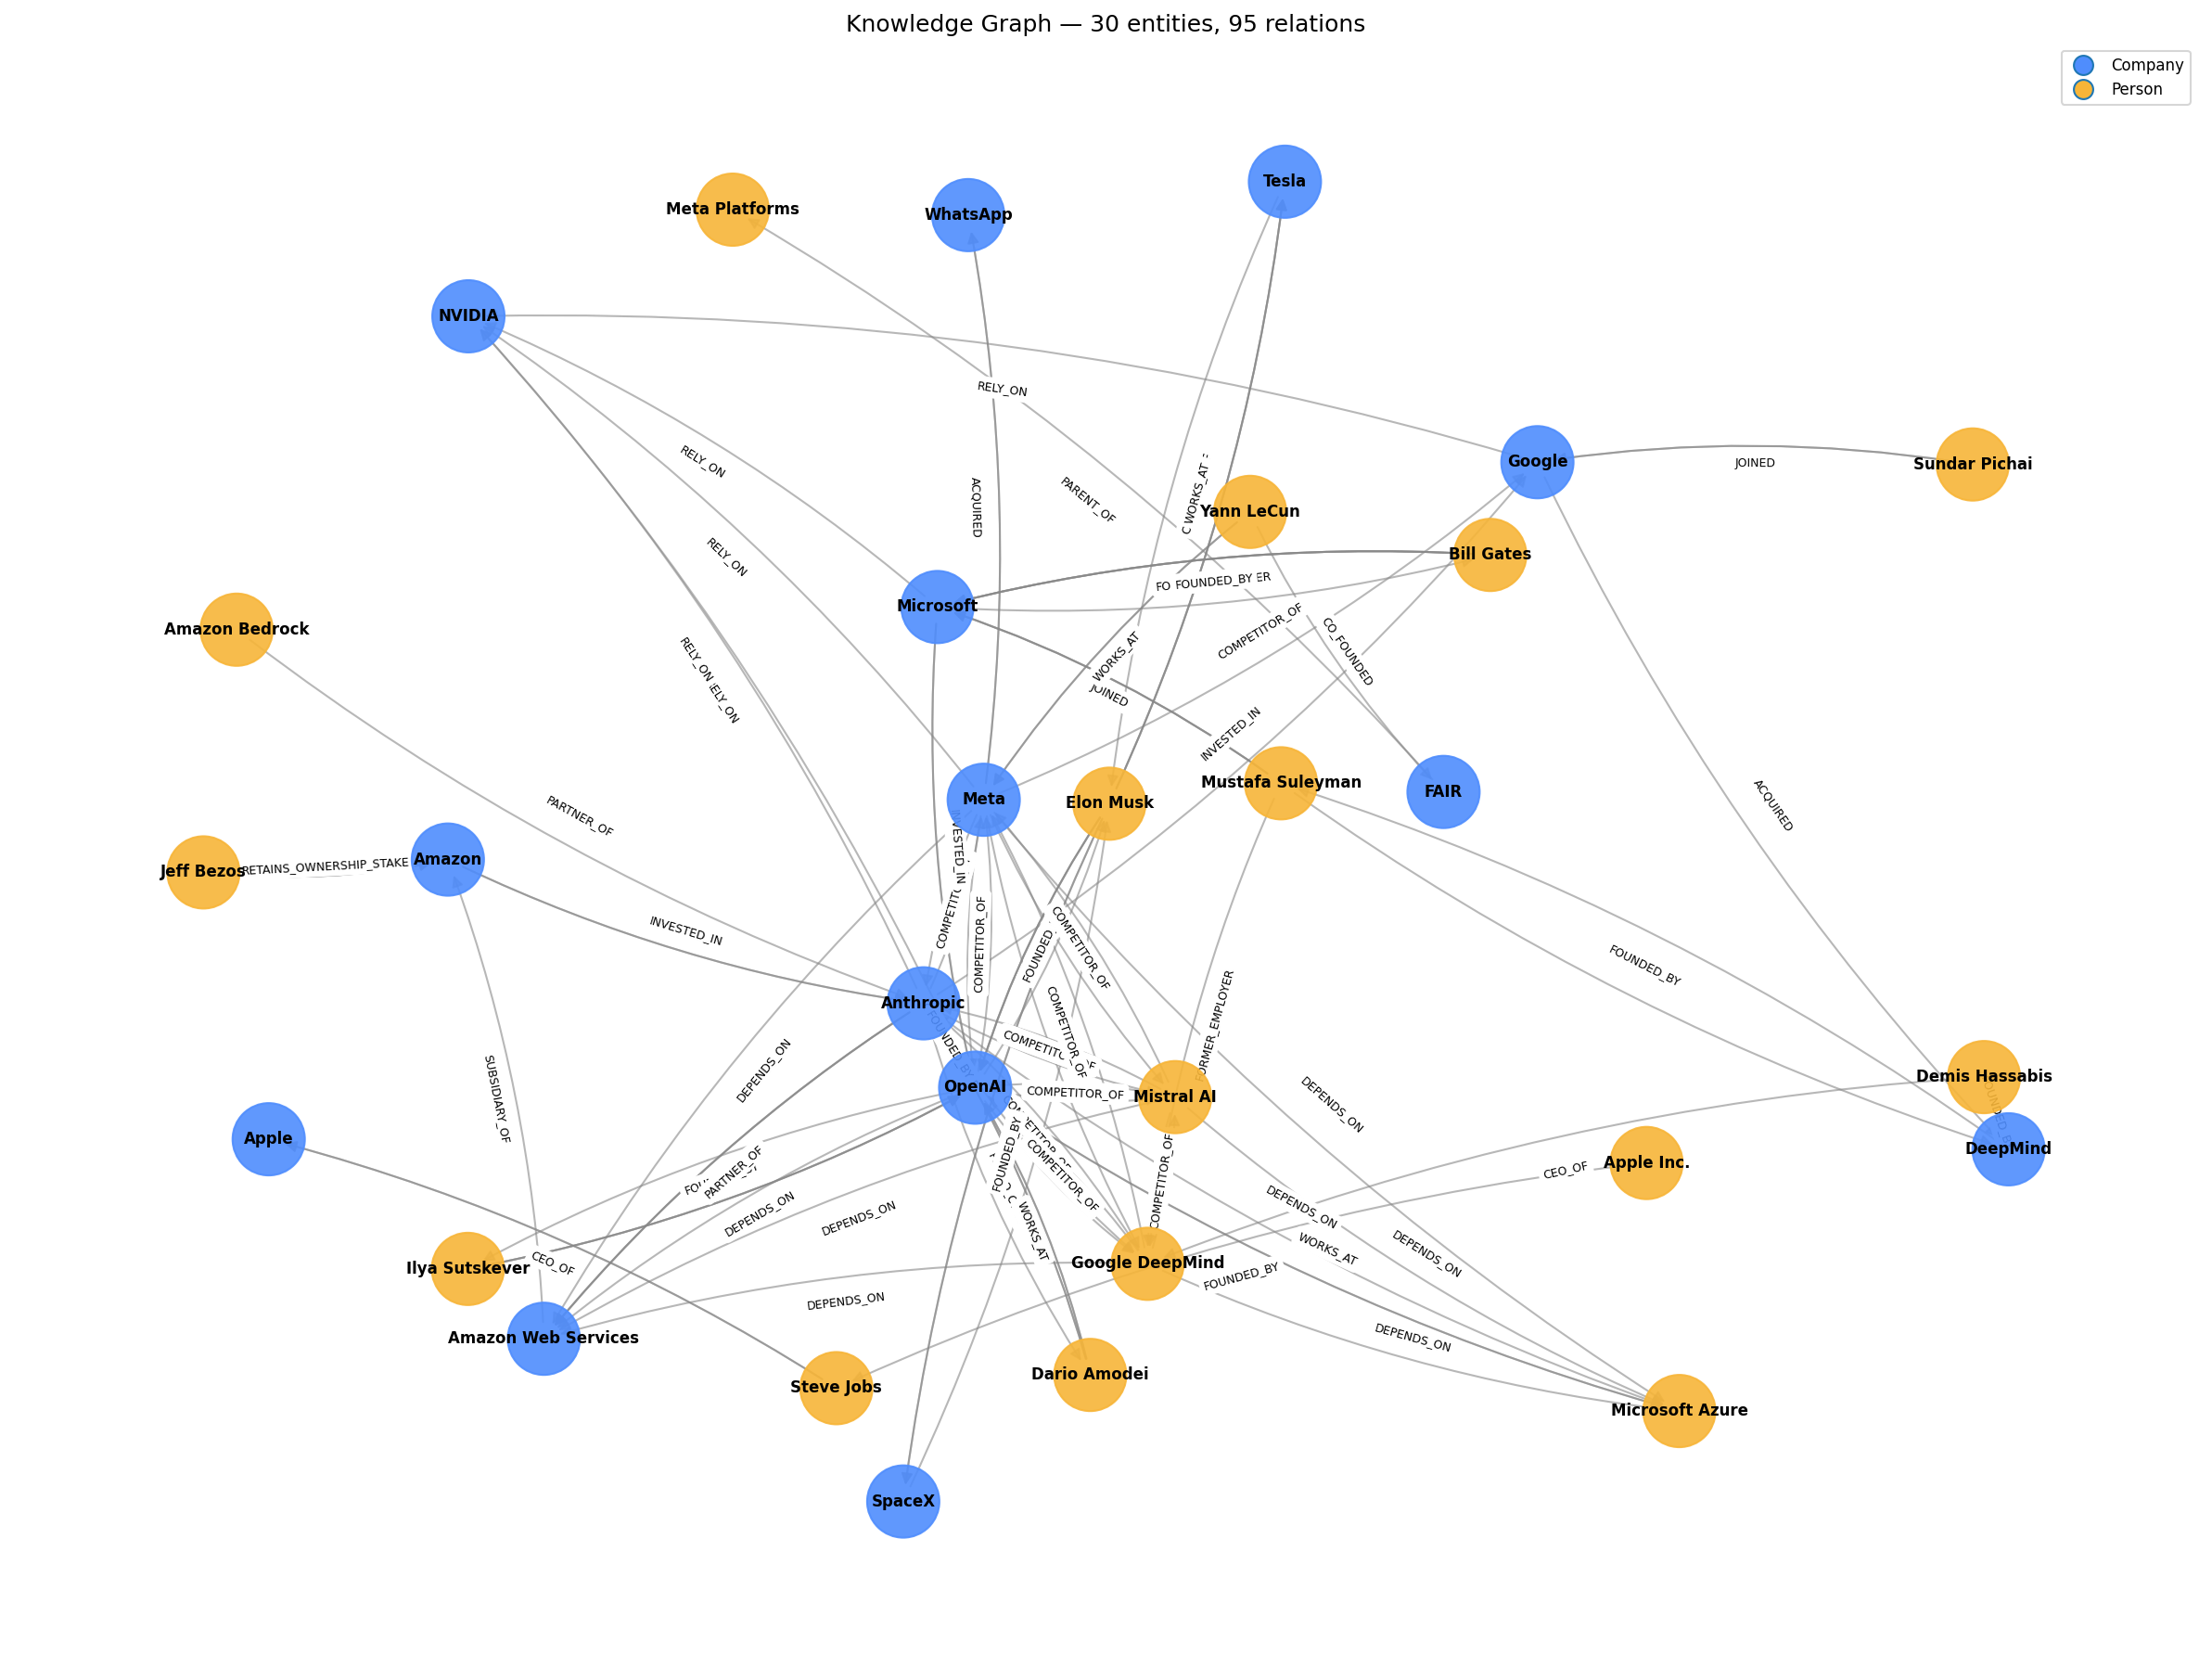

In [10]:
# Render Matplotlib backup visualization
from pathlib import Path
viz_path = PROJECT_ROOT / "screenshots" / "graph_matplotlib.png"
viz_path = export_matplotlib(viz_path, limit_nodes=30)
print(f"✓ Matplotlib visualization saved to: {viz_path}")

from IPython.display import Image, display
display(Image(filename=str(viz_path)))

### Neo4j Browser Screenshot Instructions (Deliverable #2)

1. Open **http://localhost:7474** in a browser.
2. Log in: `neo4j` / `graphrag-lab-pwd` (matches `docker-compose.yml`).
3. Paste any of the queries below into the query editor and click **Run**.
4. Adjust node spacing in the visualization until labels are readable.
5. Take a screenshot and save it as `screenshots/graph_neo4j.png`.

Recommended query for the screenshot: **"OpenAI 2-hop neighborhood"**
(it captures multi-hop structure clearly without overcrowding).

In [11]:
# Print Cypher queries to paste into Neo4j Browser
for label, query in suggested_browser_queries():
    print(f"--- {label} ---")
    print(query)
    print()

--- Full graph (use only if the graph is small enough) ---
MATCH (n)-[r]->(m) RETURN n, r, m

--- OpenAI ego network (1 hop) ---
MATCH (n {name: 'OpenAI'})-[r]-(m) RETURN n, r, m

--- OpenAI 2-hop neighborhood ---
MATCH p = (n {name: 'OpenAI'})-[*1..2]-(m) RETURN p LIMIT 100

--- Top 30 most connected entities ---
MATCH (n)-[r]-() WITH n, count(r) AS deg ORDER BY deg DESC LIMIT 30 MATCH (n)-[r2]-(m) RETURN n, r2, m

--- All companies and their CEOs ---
MATCH (p)-[r:CEO_OF]->(c) RETURN p, r, c



---
✅ **Milestone TIP-004:** Knowledge graph built with deduplication. Ready for query layer (TIP-005 GraphRAG, TIP-006 Flat RAG baseline).
---